In [1]:
import pandas as pd

df_casualty= pd.read_csv('casualty_provisional-2025.csv')
df_collision=pd.read_csv('collision_provisional-2025.csv')
df_vehical=pd.read_csv('vehicle_provisional-2025.csv')

/tmp/ipykernel_22578/102575452.py:4: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_collision=pd.read_csv('collision_provisional-2025.csv')
/tmp/ipykernel_22578/102575452.py:5: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vehical=pd.read_csv('vehicle_provisional-2025.csv')


In [2]:
vehicles_agg = df_vehical.groupby("collision_index").agg({
    "vehicle_reference": "count"
}).rename(columns={"vehicle_reference": "num_vehicles"}).reset_index()

In [13]:
vehicles_agg.columns

Index(['collision_index', 'num_vehicles'], dtype='object')

In [3]:
casualties_agg = df_casualty.groupby("collision_index").agg({
    "casualty_reference": "count"
}).rename(columns={"casualty_reference": "num_casualties"}).reset_index()

In [4]:
data = df_collision.merge(vehicles_agg, on="collision_index", how="left")
data = data.merge(casualties_agg, on="collision_index", how="left")

In [5]:
data["num_vehicles"] = data["num_vehicles"].fillna(0)
data["num_casualties"] = data["num_casualties"].fillna(0)

In [10]:
stats_summary = pd.DataFrame({
    "mean": data.mean(numeric_only=True),
    "variance": data.var(numeric_only=True),
    "std_dev": data.std(numeric_only=True)
})

stats_summary


,mean,variance,std_dev
collision_year,2025.000000,5.169985e-26,2.273760e-13
location_easting_osgr,456275.211962,8.489486e+09,9.213841e+04
location_northing_osgr,275578.665491,2.053685e+10,1.433069e+05
longitude,-1.190995,1.814199e+00,1.346922e+00
latitude,52.367636,1.667667e+00,1.291382e+00
police_force,27.489107,5.653594e+02,2.377729e+01
collision_severity,2.724459,2.283403e-01,4.778496e-01
number_of_vehicles,1.811458,4.814408e-01,6.938593e-01
number_of_casualties,1.258273,8.605492e-01,9.276579e-01
day_of_week,4.141773,3.726016e+00,1.930289e+00


In [11]:
(data.isnull().sum() / len(data)) * 100

,0
collision_index,0.000000
collision_year,0.000000
collision_ref_no,0.000000
location_easting_osgr,0.002063
location_northing_osgr,0.002063
longitude,0.002063
latitude,0.002063
police_force,0.000000
collision_severity,0.000000
number_of_vehicles,0.000000


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48472 entries, 0 to 48471
Data columns (total 46 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   collision_index                                   48472 non-null  object 
 1   collision_year                                    48472 non-null  int64  
 2   collision_ref_no                                  48472 non-null  object 
 3   location_easting_osgr                             48471 non-null  float64
 4   location_northing_osgr                            48471 non-null  float64
 5   longitude                                         48471 non-null  float64
 6   latitude                                          48471 non-null  float64
 7   police_force                                      48472 non-null  int64  
 8   collision_severity                                48472 non-null  int64  
 9   number_of_vehicle

In [6]:
data.drop(['collision_year','local_authority_district','trunk_road_flag'],axis=1,inplace=True)

In [14]:
#target distribution check
data["collision_severity"].value_counts(normalize=True)

,proportion
collision_severity,
3,0.738818
2,0.246823
1,0.014359


In [15]:
data["collision_severity"].value_counts()

,count
collision_severity,
3,35812
2,11964
1,696


In [16]:
pd.crosstab(data["weather_conditions"], data["collision_severity"], normalize="index")


collision_severity,1,2,3
weather_conditions,,,
-1,0.026066,0.180095,0.793839
1,0.014755,0.252812,0.732434
2,0.014249,0.243847,0.741904
3,0.009524,0.266667,0.723810
4,0.031373,0.270588,0.698039
5,0.026667,0.244444,0.728889
6,0.000000,0.090909,0.909091
7,0.031646,0.278481,0.689873
8,0.005009,0.189731,0.805260


In [17]:
pd.crosstab(data["light_conditions"], data["collision_severity"], normalize="index")



collision_severity,1,2,3
light_conditions,,,
-1,0.003257,0.175896,0.820847
1,0.012296,0.241288,0.746416
4,0.014259,0.251913,0.733828
5,0.028169,0.239437,0.732394
6,0.048156,0.327983,0.623861
7,0.010324,0.237463,0.752212


In [18]:
pd.crosstab(data["road_surface_conditions"], data["collision_severity"], normalize="index")


collision_severity,1,2,3
road_surface_conditions,,,
-1,0.013015,0.159436,0.827549
1,0.013946,0.249125,0.736929
2,0.017993,0.259391,0.722616
3,0.016667,0.300000,0.683333
4,0.011521,0.233871,0.754608
5,0.028571,0.285714,0.685714
9,0.000000,0.086677,0.913323


In [19]:
data.groupby("collision_severity")["speed_limit"].mean()

,speed_limit
collision_severity,
1,47.356322
2,36.875710
3,34.735396


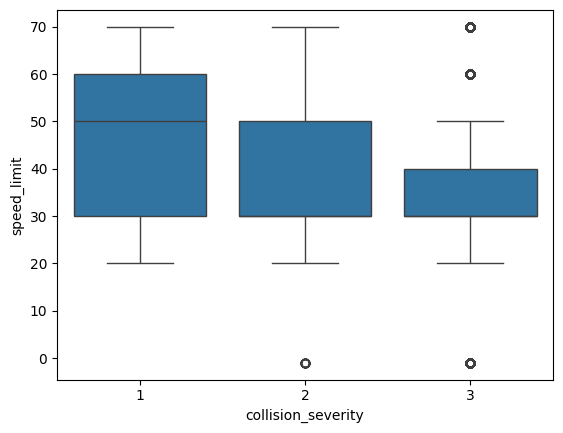

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="collision_severity", y="speed_limit", data=data)
plt.show()

<Axes: >

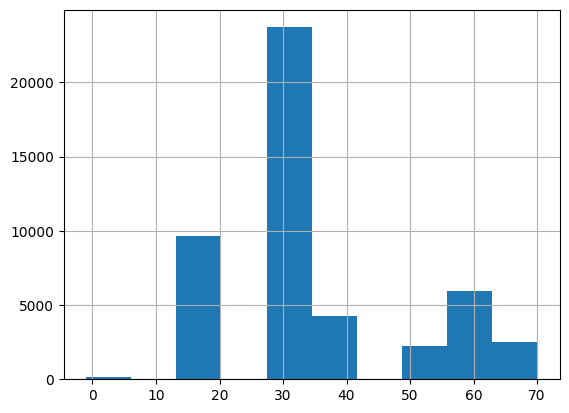

In [21]:
data["speed_limit"].hist()

In [22]:
data.corr(numeric_only=True)

,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,first_road_class,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight,num_vehicles,num_casualties
location_easting_osgr,1.000000,-0.400149,0.999492,-0.403090,-0.312875,0.077245,0.027505,-0.040940,0.004340,-0.022052,...,0.185699,0.112558,-0.118882,0.103856,-0.219839,-0.240244,-0.071553,0.082596,0.053302,-0.100183
location_northing_osgr,-0.400149,1.000000,-0.406256,0.999966,0.077396,-0.095241,-0.026486,0.030953,-0.002772,0.040557,...,-0.206104,-0.087837,0.037711,-0.098381,0.327564,0.350790,0.070884,-0.083775,0.246705,-0.013426
longitude,0.999492,-0.406256,1.000000,-0.409126,-0.322366,0.078556,0.027617,-0.040841,0.004271,-0.020019,...,0.183012,0.110978,-0.116348,0.103099,-0.218255,-0.237481,-0.072759,0.083824,0.052077,-0.097407
latitude,-0.403090,0.999966,-0.409126,1.000000,0.075667,-0.095129,-0.026516,0.030947,-0.002791,0.040562,...,-0.206180,-0.088121,0.037191,-0.098265,0.326955,0.350180,0.070917,-0.083803,0.246538,-0.013608
police_force,-0.312875,0.077396,-0.322366,0.075667,1.000000,-0.087869,0.006856,0.050199,-0.003425,0.033487,...,-0.270702,-0.155476,0.287423,-0.145644,0.320141,0.348717,0.091441,-0.099790,-0.260769,0.538593
collision_severity,0.077245,-0.095241,0.078556,-0.095129,-0.087869,1.000000,0.051884,-0.073233,0.000794,0.007121,...,0.082322,0.063947,-0.095263,0.189094,-0.374087,-0.090937,-0.861177,0.965151,0.043723,-0.094025
number_of_vehicles,0.027505,-0.026486,0.027617,-0.026516,0.006856,0.051884,1.000000,0.140048,0.000719,-0.130764,...,-0.011927,-0.013203,0.055885,-0.020143,-0.003543,0.017407,-0.057111,0.057851,0.540848,0.133042
number_of_casualties,-0.040940,0.030953,-0.040841,0.030947,0.050199,-0.073233,0.140048,1.000000,-0.006669,-0.060975,...,-0.045433,-0.035408,0.107834,-0.093730,0.050332,0.047603,0.059896,-0.071956,0.061105,0.474755
day_of_week,0.004340,-0.002772,0.004271,-0.002791,-0.003425,0.000794,0.000719,-0.006669,1.000000,0.000210,...,0.005808,0.006341,-0.018128,-0.004351,-0.005263,-0.005686,-0.000255,0.000785,0.003443,-0.008080
first_road_class,-0.022052,0.040557,-0.020019,0.040562,0.033487,0.007121,-0.130764,-0.060975,0.000210,1.000000,...,-0.047125,-0.016796,-0.173311,0.045397,0.082128,0.085372,0.013023,-0.003815,-0.090933,0.007937


<Axes: >

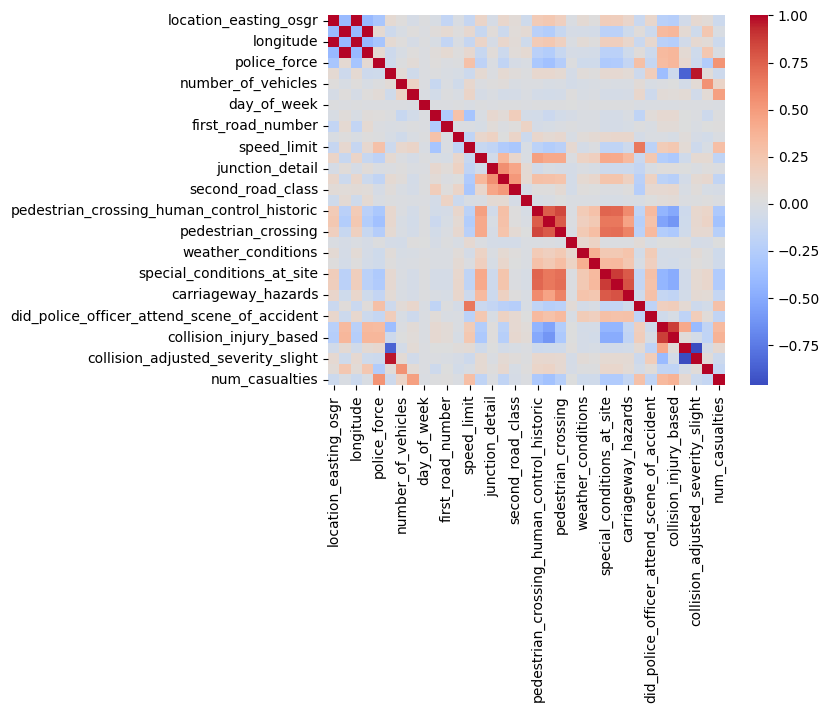

In [23]:
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm")

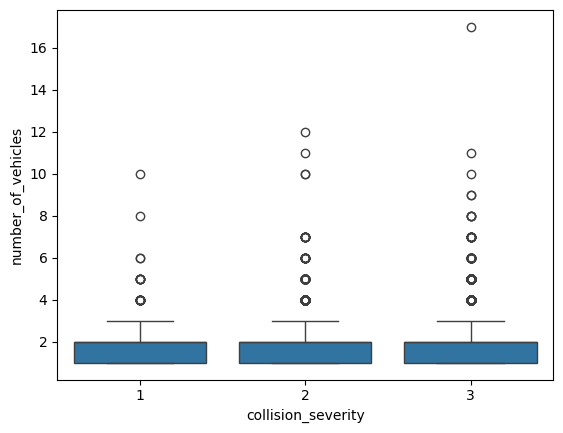

In [24]:
sns.boxplot(x="collision_severity", y="number_of_vehicles", data=data)
plt.show()

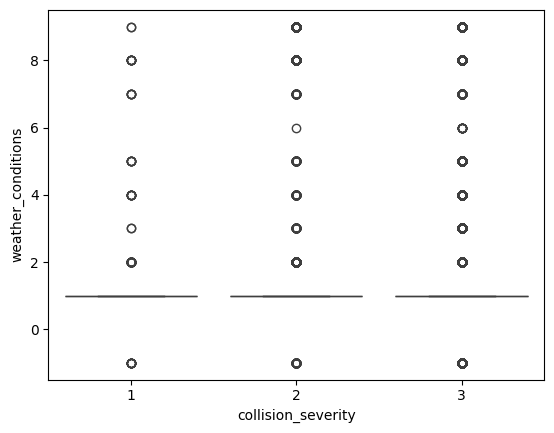

In [25]:

sns.boxplot(x="collision_severity", y="weather_conditions", data=data)
plt.show()

In [26]:
pd.crosstab(data["weather_conditions"], data["collision_severity"], normalize="index")

collision_severity,1,2,3
weather_conditions,,,
-1,0.026066,0.180095,0.793839
1,0.014755,0.252812,0.732434
2,0.014249,0.243847,0.741904
3,0.009524,0.266667,0.723810
4,0.031373,0.270588,0.698039
5,0.026667,0.244444,0.728889
6,0.000000,0.090909,0.909091
7,0.031646,0.278481,0.689873
8,0.005009,0.189731,0.805260


In [27]:
pd.crosstab(data["light_conditions"], data["collision_severity"], normalize="index")

collision_severity,1,2,3
light_conditions,,,
-1,0.003257,0.175896,0.820847
1,0.012296,0.241288,0.746416
4,0.014259,0.251913,0.733828
5,0.028169,0.239437,0.732394
6,0.048156,0.327983,0.623861
7,0.010324,0.237463,0.752212


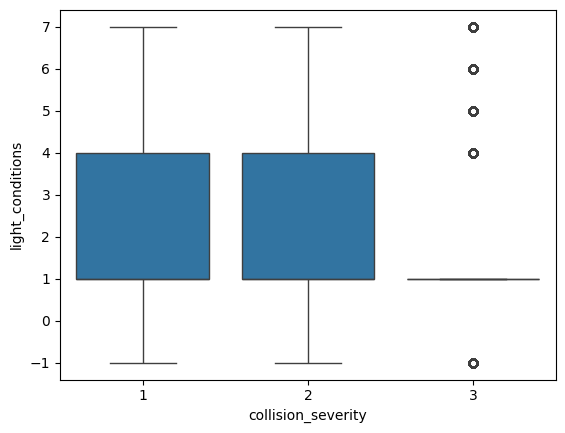

In [28]:
sns.boxplot(x="collision_severity", y="light_conditions", data=data)
plt.show()

In [29]:
pd.crosstab(data["urban_or_rural_area"], data["collision_severity"], normalize="index")

collision_severity,1,2,3
urban_or_rural_area,,,
1,0.007559,0.228143,0.764298
2,0.027917,0.284108,0.687975
3,0.000000,0.000000,1.000000


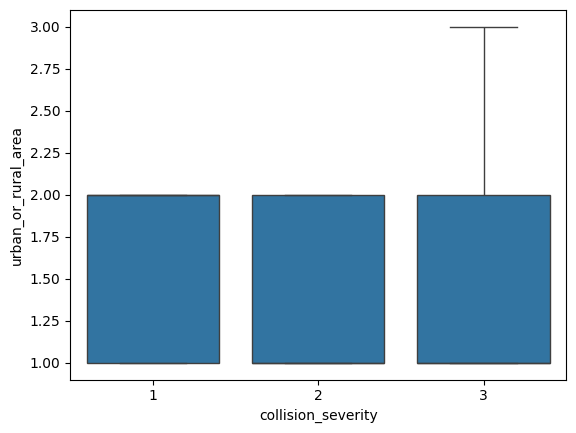

In [30]:
sns.boxplot(x="collision_severity", y="urban_or_rural_area", data=data)
plt.show()

In [31]:
data["urban_or_rural_area"].value_counts()

,count
urban_or_rural_area,
1,32278
2,16191
3,3


In [32]:
data.corr(numeric_only=True)["collision_severity"].sort_values()

,collision_severity
collision_adjusted_severity_serious,-0.861177
enhanced_severity_collision,-0.374087
speed_limit,-0.099275
urban_or_rural_area,-0.095263
location_northing_osgr,-0.095241
latitude,-0.095129
num_casualties,-0.094025
collision_injury_based,-0.090937
police_force,-0.087869
number_of_casualties,-0.073233


In [7]:
data = data[data["urban_or_rural_area"] != 3]

In [8]:
data = data.drop(columns=[
    "collision_adjusted_severity_slight",
    "collision_adjusted_severity_serious",
    "enhanced_severity_collision",
    "collision_injury_based"
])

In [35]:
from scipy.stats import chi2_contingency

# Example: light_conditions
contingency_table = pd.crosstab(data["light_conditions"], data["collision_severity"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("p-value:", p)

p-value: 3.3865823658826077e-63


In [36]:
from scipy.stats import chi2_contingency

# Example: light_conditions
contingency_table = pd.crosstab(data["weather_conditions"], data["collision_severity"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("p-value:", p)

p-value: 3.7997997406541566e-28


In [37]:
from scipy.stats import chi2_contingency

# Example: light_conditions
contingency_table = pd.crosstab(data["urban_or_rural_area"], data["collision_severity"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("p-value:", p)

p-value: 1.806561161350166e-116


In [38]:
from scipy.stats import chi2_contingency

# Example: light_conditions
contingency_table = pd.crosstab(data["road_type"], data["collision_severity"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("p-value:", p)

p-value: 5.372665942919286e-71


In [39]:
from scipy.stats import f_oneway

group1 = data[data["collision_severity"] == 1]["speed_limit"]
group2 = data[data["collision_severity"] == 2]["speed_limit"]
group3 = data[data["collision_severity"] == 3]["speed_limit"]

stat, p = f_oneway(group1, group2, group3)

print("p-value:", p)

p-value: 1.2857492135513348e-144


In [40]:
from scipy.stats import f_oneway

group1 = data[data["collision_severity"] == 1]["number_of_vehicles"]
group2 = data[data["collision_severity"] == 2]["number_of_vehicles"]
group3 = data[data["collision_severity"] == 3]["number_of_vehicles"]

stat, p = f_oneway(group1, group2, group3)

print("p-value:", p)

p-value: 1.6579778873727536e-32


In [41]:
from scipy.stats import f_oneway

group1 = data[data["collision_severity"] == 1]["number_of_casualties"]
group2 = data[data["collision_severity"] == 2]["number_of_casualties"]
group3 = data[data["collision_severity"] == 3]["number_of_casualties"]

stat, p = f_oneway(group1, group2, group3)

print("p-value:", p)

p-value: 1.0157268928263861e-60


In [9]:
cols_to_drop = [
    "collision_index",
    "date",
    "time",
    "location_easting_osgr",
    "location_northing_osgr",
    "longitude",
    "latitude",
    "first_road_number",
    "second_road_number"
]

cols_to_drop = [c for c in cols_to_drop if c in data.columns]

data_model = data.drop(columns=cols_to_drop)
from sklearn.preprocessing import LabelEncoder
# target
y = data_model["collision_severity"]

# features
X = data_model.drop(columns=["collision_severity"])

# label encode only object/category columns
label_encoders = {}

cat_cols = X.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("Encoded columns:", list(cat_cols))
print("X shape:", X.shape)

Encoded columns: ['collision_ref_no', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'lsoa_of_accident_location']
X shape: (48469, 29)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight={1:10, 2:5, 3:1},  # manually boost minority
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.14      0.01      0.01       139
           2       0.39      0.11      0.17      2393
           3       0.75      0.95      0.84      7162

    accuracy                           0.73      9694
   macro avg       0.43      0.35      0.34      9694
weighted avg       0.65      0.73      0.66      9694

[[   1   21  117]
 [   2  266 2125]
 [   4  387 6771]]


In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(model, X, y, cv=5, scoring="f1_weighted")

print("Scores:", scores)
print("Mean F1:", scores.mean())

Scores: [0.62823857 0.36254702 0.4994889  0.49722164 0.28473369]
Mean F1: 0.45444596668414033


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5)

scores = cross_val_score(model, X, y, cv=skf, scoring="f1_weighted")



In [16]:
print(scroes)

NameError: name 'scroes' is not defined

In [17]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

data_model = data.copy()

drop_cols = [
    "collision_index",
    "collision_adjusted_severity_slight",
    "collision_adjusted_severity_serious",
    "enhanced_severity_collision",
    "collision_injury_based",
    "collision_year",
    "local_authority_district",
    "trunk_road_flag"
]

drop_cols = [c for c in drop_cols if c in data_model.columns]
data_model = data_model.drop(columns=drop_cols)

X = data_model.drop("collision_severity", axis=1)
y = data_model["collision_severity"]

label_encoders = {}
cat_cols = X.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

y = y.replace({1: 0, 2: 1, 3: 2})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.01      0.01       139
           1       0.49      0.09      0.15      2393
           2       0.75      0.97      0.85      7162

    accuracy                           0.74      9694
   macro avg       0.58      0.36      0.34      9694
weighted avg       0.68      0.74      0.66      9694

[[   1   23  115]
 [   0  207 2186]
 [   1  195 6966]]


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: collision_severity
2    28647
1     9571
0      557
Name: count, dtype: int64
After SMOTE: collision_severity
2    28647
1    28647
0    28647
Name: count, dtype: int64


In [19]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

In [20]:
y_pred = xgb_model.predict(X_test)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.10      0.04      0.06       139
           1       0.41      0.13      0.19      2393
           2       0.76      0.94      0.84      7162

    accuracy                           0.72      9694
   macro avg       0.42      0.37      0.36      9694
weighted avg       0.66      0.72      0.67      9694

[[   6   23  110]
 [  25  305 2063]
 [  29  416 6717]]


In [25]:
y_binary = y.replace({0:1, 1:1, 2:0})
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_binary, y_test_binary = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)
print(y_train_binary.value_counts(normalize=True))

collision_severity
0    0.738801
1    0.261199
Name: proportion, dtype: float64


In [26]:
from xgboost import XGBClassifier

xgb_binary = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=3,  # adjust based on imbalance
    random_state=42,
    eval_metric="logloss"
)

xgb_binary.fit(X_train, y_train_binary)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = xgb_binary.predict(X_test)

print(classification_report(y_test_binary, y_pred))
print(confusion_matrix(y_test_binary, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.63      0.72      7162
           1       0.37      0.61      0.46      2532

    accuracy                           0.63      9694
   macro avg       0.60      0.62      0.59      9694
weighted avg       0.70      0.63      0.65      9694

[[4528 2634]
 [ 975 1557]]
